# Autoencoders and Variational Autoencoders (VAE) for Dimensionality Reduction

---

## Learning Outcomes

By the end of this notebook, you will be able to:

1. Explain what autoencoders and VAEs are and why they exist.
2. Build a from-scratch intuition using NumPy.
3. Implement a production-grade autoencoder and VAE using TensorFlow/Keras.
4. Compare reconstruction quality and latent space representations.
5. Answer interview questions about autoencoders, VAEs, latent space, and dimensionality reduction.

---

## Prerequisites

- Basic Python (variables, loops, functions, arrays).
- Basic NumPy (arrays, shapes, basic operations).
- Familiarity with neural network concepts (layers, activations, training) is helpful but not required.

---

## Dataset Links

- **OpenML MNIST:** https://www.openml.org/d/554
- **Kaggle MNIST:** https://www.kaggle.com/datasets/hojjatk/mnist-dataset

---

## Why This Dataset Was Chosen

You could generate random dots on a grid and call it a dataset — but you would not learn anything by compressing noise. MNIST lets you SEE what worked and what got lost.

It contains 70,000 images of handwritten digits (0–9), each 28×28 pixels grayscale. This is small enough to train on a laptop in minutes. The digits are simple shapes, so when the reconstruction is blurry or missing a loop, you notice immediately.

Think of it this way: if you describe a stick-figure drawing to a friend over the phone, you can tell if they drew it back correctly. MNIST gives us that same clarity: we see exactly what information survived compression and what vanished.

In [1]:
# numpy: core array and math operations
import numpy as np
# pandas: data handling
import pandas as pd
# matplotlib: plotting and visualization
import matplotlib.pyplot as plt
# seaborn: enhanced plot styling
import seaborn as sns
# fetch_openml: download MNIST dataset
from sklearn.datasets import fetch_openml
# train_test_split: split data into train and test sets
from sklearn.model_selection import train_test_split
# Set Keras backend to PyTorch before importing Keras
import os
os.environ['KERAS_BACKEND'] = 'torch'
# keras: deep learning framework for autoencoders and VAEs
import keras
from keras import layers, Model

# Set random seeds for reproducibility
np.random.seed(42)
keras.utils.set_random_seed(42)

# Set plot style
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120})

---

# PART 1 — THEORY RECAP

---

## What is an Autoencoder?

An **autoencoder** is a neural network that learns to copy its input to its output. It has two parts:

- **Encoder:** Compresses the input into a smaller representation (latent space).
- **Decoder:** Reconstructs the original input from that compressed representation.

**Analogy:** Imagine you need to describe a photograph over the phone using only 10 words. You compress (encode) the image into a short description, and the listener tries to reconstruct (decode) the image in their mind. The better your description, the closer the reconstruction.

---

## What is a VAE (Variational Autoencoder)?

A **VAE** is a probabilistic twist on the autoencoder. Instead of producing a single point in latent space, the encoder outputs a **probability distribution** (mean and variance). The decoder then samples from this distribution to reconstruct the input.

**Analogy:** Instead of saying "the digit is a 7," you say "I am 90% confident it is a 7, and there is a small chance it could be a 1 or a 9." This uncertainty makes the latent space smooth and continuous, enabling **generation** of new data.

---

## Why Autoencoders Exist

Autoencoders were created to learn **useful representations** of data without requiring labeled examples. They are an **unsupervised learning** technique — they learn from the data itself, not from labels.

---

## Why Dimensionality Reduction is Needed

High-dimensional data (e.g., a 28×28 image = 784 dimensions) suffers from:

- **Curse of dimensionality:** Distances become meaningless in high dimensions.
- **Computational cost:** More dimensions mean more parameters and slower training.
- **Overfitting:** Models can memorize noise rather than learn patterns.
- **Visualization:** Humans cannot visualize data beyond 3 dimensions.

Reducing dimensions to a compact latent space solves all these problems.

---

## Autoencoder Intuition

Think of an autoencoder as a **data-specific compression algorithm**. Unlike JPEG or ZIP (which work on any image), an autoencoder learns to compress only the kind of data it was trained on. An autoencoder trained on handwritten digits will compress digits well but fail to compress a photograph of a cat.

**Loss function:** The difference between input and reconstruction (e.g., Mean Squared Error). The network minimizes this loss, forcing the bottleneck to preserve the most important features.

---

## VAE Intuition

A standard autoencoder learns a **deterministic** mapping: one input produces one fixed latent point. The latent space may have "gaps" — points between clusters that do not correspond to any valid digit. If you pick a random point in the middle, you get noise, not a digit.

A VAE fixes this by learning a **probability distribution** instead of a single point. Imagine asking five doctors to examine an X-ray. Each might give a slightly different diagnosis — there is a range of plausible answers. The VAE encoder outputs not one value but a mean (the average diagnosis) and a variance (how much the doctors disagree). The decoder then works with a sample drawn from this distribution.

**Analogy:** A standard autoencoder is like memorizing the exact answer to an exam question. A VAE is like understanding the topic so well you can answer any question in that area — even ones you have never seen.

**Key addition:** The VAE loss has two terms:

1. **Reconstruction loss** (like a standard autoencoder) — measures how well the output matches the input.
2. **KL divergence loss** — measures how far the learned distribution is from a standard bell curve (mean=0, variance=1). Think of this as a "regularization tax": the latent space must stay close to a standard normal distribution. This prevents the model from spreading out too wildly and creates a smooth, continuous space.

This allows VAEs to **generate new data** by sampling random points from the latent space — a capability standard autoencoders lack. You can draw a point from the standard normal distribution, pass it through the decoder, and get a brand-new digit that looks realistic.

---

# Dataset Introduction

## What is MNIST?

Imagine someone handed you 70,000 handwritten sticky notes, each with a single digit (0–9) scribbled on it. Some are neat, some messy, some tilted. That is MNIST — the **Modified National Institute of Standards and Technology** dataset.

Every image is a tiny 28-by-28 grid of gray squares (pixels). Each square has a brightness value from 0 (black) to 255 (white). The whole image is just a string of 784 numbers.

- **Training set:** 60,000 images
- **Test set:** 10,000 images

## Why is MNIST Useful?

- **Fits on a laptop:** 70,000 images at 784 pixels each is tiny by modern standards.
- **You can SEE the mistakes:** When reconstruction fails, you see a blurry digit — no need to stare at abstract metrics.
- **Limited variety:** Digits share common structures (loops, straight lines, curves). This makes compression learnable without needing a massive model.
- **Industry baseline:** Thousands of papers report results on MNIST, making it a reliable benchmark.

## Expected Observations

- The production autoencoder should reconstruct test digits that look nearly identical to the originals.
- The VAE may produce slightly softer (blurrier) reconstructions, but it will generate smooth transitions between digits.
- The latent space, when squeezed down to 2D, will naturally separate the 10 digit types — without ever being told what a "4" or a "9" is.

Loading MNIST dataset from OpenML...
Dataset shape: (70000, 784)
Labels shape: (70000,)
Pixel range: [0, 255]
Number of classes: 10
Class distribution:
  Digit 0: 6903 samples
  Digit 1: 7877 samples
  Digit 2: 6990 samples
  Digit 3: 7141 samples
  Digit 4: 6824 samples
  Digit 5: 6313 samples
  Digit 6: 6876 samples
  Digit 7: 7293 samples
  Digit 8: 6825 samples
  Digit 9: 6958 samples


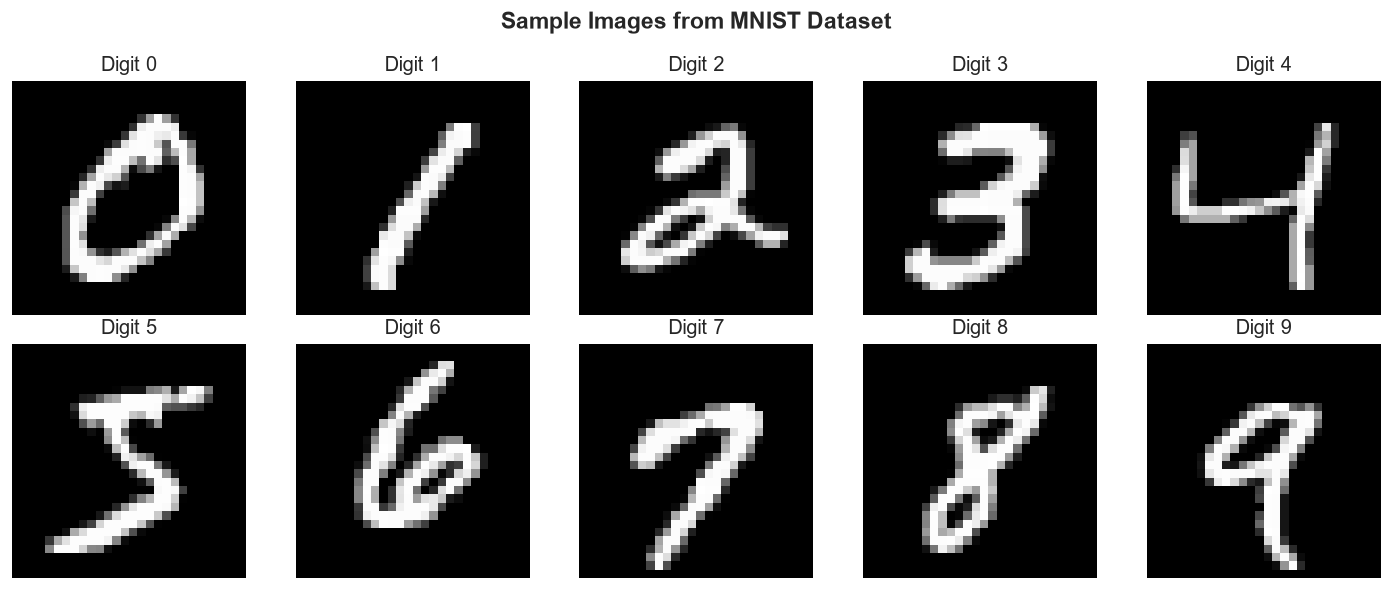

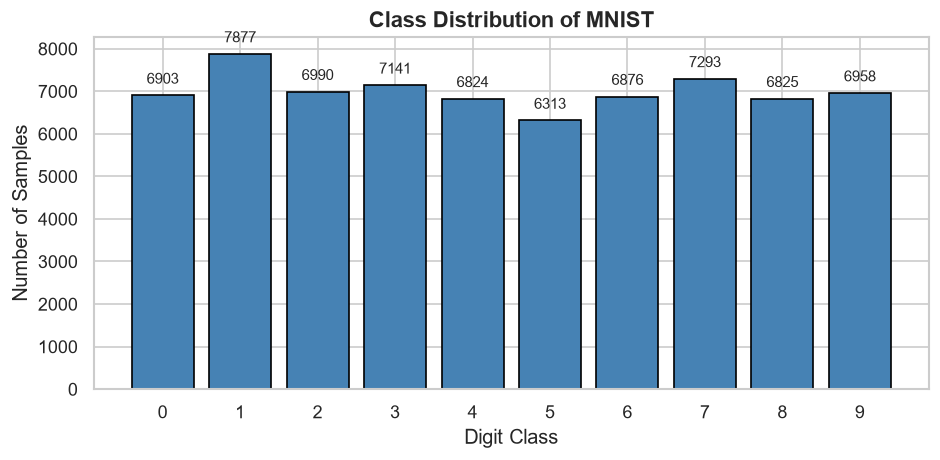


Dataset loaded successfully!


In [2]:
# Load MNIST from OpenML
print("Loading MNIST dataset from OpenML...")
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False, parser='auto')

# Convert labels to integers
y = y.astype(np.int32)

# Display dataset shape
print(f"Dataset shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Pixel range: [{X.min()}, {X.max()}]")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Class distribution:")
for digit in range(10):
    count = np.sum(y == digit)
    print(f"  Digit {digit}: {count} samples")

# Visualize sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Sample Images from MNIST Dataset", fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flat):
    idx = np.where(y == i)[0][0]
    img = X[idx].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Digit {i}")
    ax.axis('off')
plt.tight_layout()
plt.savefig('mnist_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

# Visualize class distribution
fig, ax = plt.subplots(figsize=(8, 4))
unique, counts = np.unique(y, return_counts=True)
bars = ax.bar(unique, counts, color='steelblue', edgecolor='black')
ax.set_title("Class Distribution of MNIST", fontsize=13, fontweight='bold')
ax.set_xlabel("Digit Class")
ax.set_ylabel("Number of Samples")
ax.set_xticks(unique)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            str(count), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('mnist_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nDataset loaded successfully!")

---

# Preprocessing Explanation

Before feeding images into a neural network, we must prepare them:

## 1. Normalization

Neural networks work best when inputs are in the range [0, 1] or [-1, 1]. Large values (0–255) can cause gradients to explode or make training unstable. We divide by 255.0 to scale every pixel to [0, 1].

## 2. Reshaping

Each image is stored as a flat 784-dimensional vector. We keep this shape for the autoencoder (dense layers expect flat inputs). Later, for convolutional autoencoders, we would reshape to 28×28×1.

## 3. Train/Test Split

We split the data into:
- **Training set (80%):** Used to train the autoencoder.
- **Test set (20%):** Held out to evaluate reconstruction on unseen data.

We use `train_test_split` with `random_state=42` for reproducibility.

In [3]:
# Normalize pixel values to [0, 1] and convert to float32
X = X / 255.0
X = X.astype(np.float32)

# Split into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"\nAfter normalization:")
print(f"  Pixel range: [{X_train.min():.4f}, {X_train.max():.4f}]")
print(f"  Mean: {X_train.mean():.4f}")
print(f"  Std:  {X_train.std():.4f}")
print("\nPreprocessing complete!")

Training set shape: (56000, 784)
Test set shape: (14000, 784)

After normalization:
  Pixel range: [0.0000, 1.0000]
  Mean: 0.1311
  Std:  0.3086

Preprocessing complete!


---

# PART 2 — FROM-SCRATCH AUTOENCODER INTUITION

## Encoder

The encoder is the "compressor." It takes the original 784 numbers (the 28×28 image) and squeezes them into a much smaller set of numbers — say 32. It decides which visual features matter (stroke thickness, curvature, position) and discards the rest.

## Bottleneck (Latent Space)

The bottleneck is the narrowest layer in the network — the point of maximum compression. Think of it as a narrow doorway: only the most essential information squeezes through. If the doorway is too narrow (2 numbers instead of 32), too much information gets lost and the reconstruction becomes unrecognizable.

## Decoder

The decoder is the "uncompressor." It takes the 32 compressed numbers and tries to rebuild the original 784 pixels. It must learn how to "inflate" the compressed representation back into a recognizable digit.

## Reconstruction

The reconstruction is the decoder's output — the autoencoder's best guess at recreating the original image. We measure how good this guess is using Mean Squared Error: for every pixel, we square the difference between the original value and the reconstructed value, then average across all pixels. Lower error means better reconstruction.

## Why Not Use NumPy for Production?

Building a full neural network in raw NumPy means writing:

- Backpropagation formulas by hand for every layer type
- Gradient descent optimizers (Adam alone takes ~50 lines)
- Mini-batch data loaders with shuffling
- GPU kernel launches from scratch
- Weight initialization schemes (Xavier, He, etc.)
- Dropout, batch normalization, and other regularizers

That is hundreds to thousands of lines where a single sign error breaks everything silently. Frameworks like TensorFlow and PyTorch handle all of this reliably. The NumPy example below serves one purpose: showing the **core loop** of compress → reconstruct → measure error → adjust weights. It is deliberately stripped down — a teaching tool, not a production model.

Epoch  20/100  |  Loss: 0.062137
Epoch  40/100  |  Loss: 0.053950
Epoch  60/100  |  Loss: 0.044218
Epoch  80/100  |  Loss: 0.038859
Epoch 100/100  |  Loss: 0.035494

Final loss: 0.035494


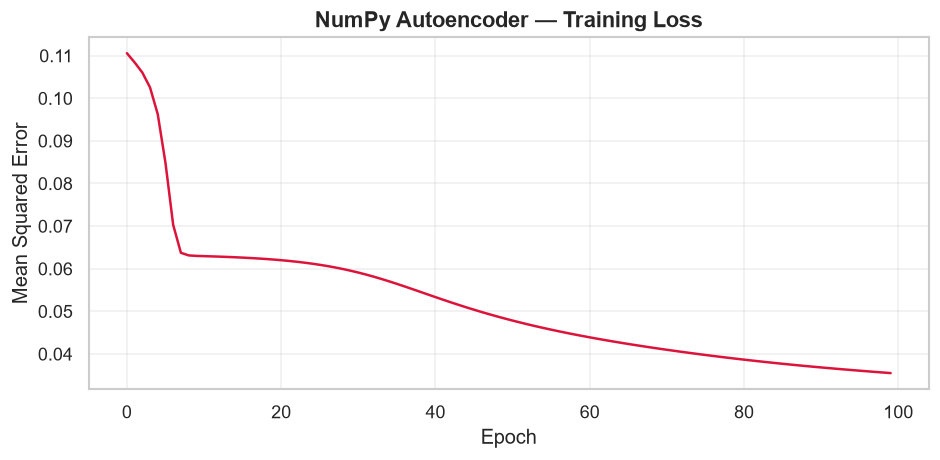

In [4]:
"""
Simplified NumPy-based Autoencoder Intuition

This is NOT a production model. It demonstrates the core idea:
  - Encoder: W1 @ x + b1  (linear compression)
  - Decoder: W2 @ z + b2  (linear reconstruction)

We learn W1, b1, W2, b2 using a simple gradient descent loop.
This has NO hidden layers, NO activation functions, and NO batching.
"""

np.random.seed(42)

# Hyperparameters
latent_dim = 32
learning_rate = 0.01
n_epochs = 100

# Use a small subset for speed
n_samples = 500
X_subset = X_train[:n_samples]

input_dim = X_subset.shape[1]

# Initialize weights and biases
W1 = np.random.randn(input_dim, latent_dim) * 0.01
b1 = np.zeros((1, latent_dim))
W2 = np.random.randn(latent_dim, input_dim) * 0.01
b2 = np.zeros((1, input_dim))

# Training loop
loss_history = []
for epoch in range(n_epochs):
    # Forward pass
    z = X_subset @ W1 + b1
    X_recon = z @ W2 + b2

    # Mean Squared Error loss
    error = X_recon - X_subset
    loss = np.mean(error ** 2)
    loss_history.append(loss)

    # Gradients (manual backpropagation)
    dL_dX_recon = 2 * error / n_samples
    dL_dW2 = z.T @ dL_dX_recon
    dL_db2 = np.sum(dL_dX_recon, axis=0, keepdims=True)
    dL_dz = dL_dX_recon @ W2.T
    dL_dW1 = X_subset.T @ dL_dz
    dL_db1 = np.sum(dL_dz, axis=0, keepdims=True)

    # Update parameters
    W2 -= learning_rate * dL_dW2
    b2 -= learning_rate * dL_db2
    W1 -= learning_rate * dL_dW1
    b1 -= learning_rate * dL_db1

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch + 1:3d}/{n_epochs}  |  Loss: {loss:.6f}")

print(f"\nFinal loss: {loss:.6f}")

# Plot training loss
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(loss_history, color='crimson', linewidth=1.5)
ax.set_title("NumPy Autoencoder — Training Loss", fontsize=13, fontweight='bold')
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean Squared Error")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('numpy_ae_loss.png', dpi=150, bbox_inches='tight')
plt.show()

---

# Interpret Results

## Compression

The encoder compresses 784 pixel values into **32 latent dimensions** — a **24.5× compression ratio**. To put this in perspective: imagine summarizing a 784-page book into 32 sentences. You would keep the plot, the main characters, and the setting — but lose the descriptive details, the subplots, and the writing style.

The network faces the same challenge. It must keep what matters most: Is the digit curvy or straight? Does it have a loop? Is it centered or tilted? Everything else (exact pixel brightness, paper texture, ink variation) gets discarded.

## Reconstruction

The decoder attempts to rebuild the 784 original pixels from the 32 compressed numbers. Because our NumPy model uses only linear transformations (no ReLU, no sigmoid), it acts like a glorified matrix multiplication — it can only mix and scale pixels, not create curved strokes or sharp edges. The result will look like a **blurry ghost** of the original digit.

## Information Loss

Three reasons the reconstruction is imperfect:

1. **Bottleneck constraint:** You gave the model only 32 numbers to carry all the information. Some information simply does not fit.
2. **No nonlinearity:** A linear model can only represent straight-line combinations. Handwritten digits are full of curves, loops, and varying stroke widths — all nonlinear. This is like trying to describe a circle using only straight lines.
3. **Simple training:** Our gradient descent uses a fixed learning rate with no momentum or adaptation. Production optimizers (Adam) adjust the step size per parameter and converge to much better solutions.

Despite these limitations, the core idea is visible: the network learns to compress and reconstruct. You will see the blurry shape of each digit preserved, even if the fine details are gone.

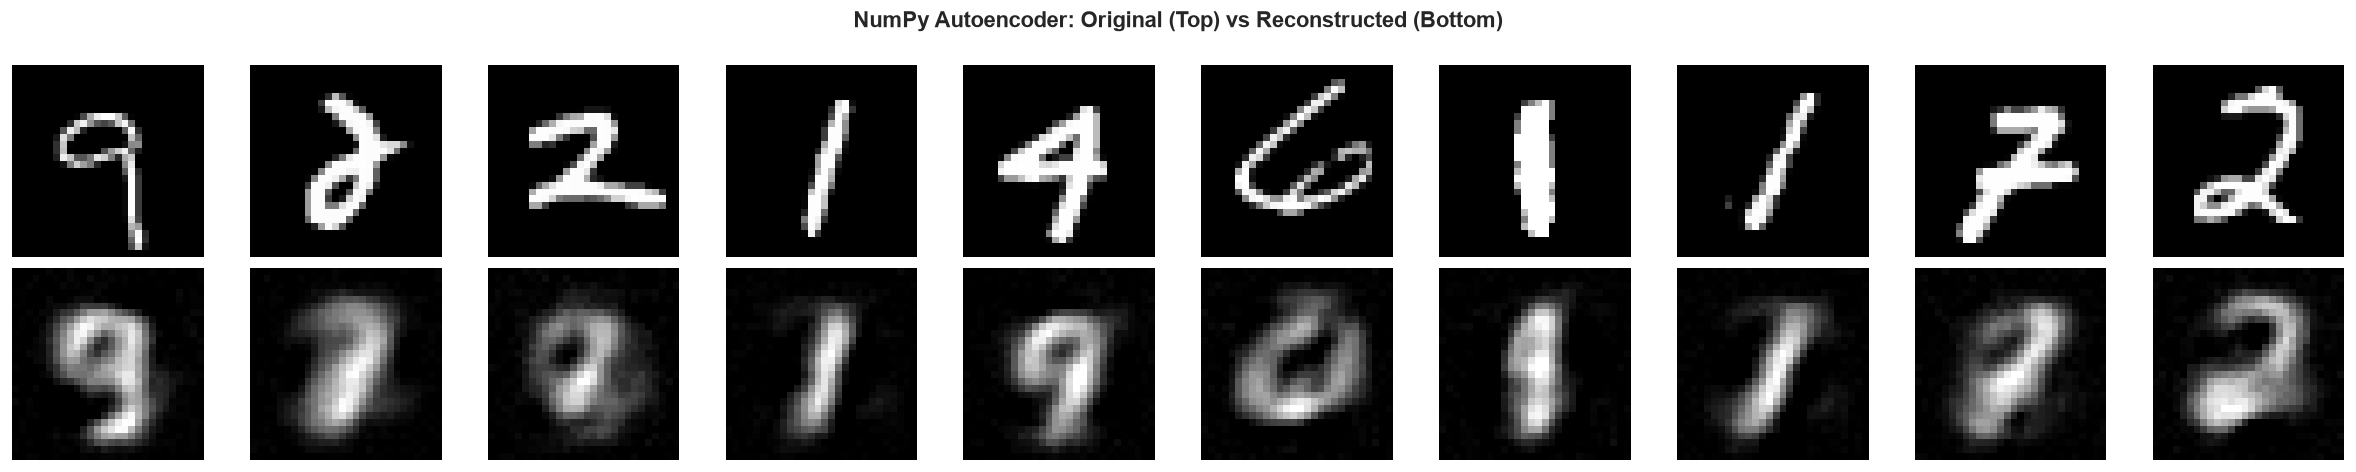

Average reconstruction error (MSE) on test set: 0.036442


In [5]:
# Visualize original vs reconstructed images from NumPy autoencoder
n_show = 10
indices = np.random.choice(X_test.shape[0], n_show, replace=False)

original = X_test[indices]
z_test = original @ W1 + b1
reconstructed = np.clip(z_test @ W2 + b2, 0, 1)

fig, axes = plt.subplots(2, n_show, figsize=(2 * n_show, 4))
fig.suptitle("NumPy Autoencoder: Original (Top) vs Reconstructed (Bottom)",
             fontsize=13, fontweight='bold')
for i in range(n_show):
    axes[0, i].imshow(original[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel("Original", fontsize=10)
    axes[1, i].imshow(reconstructed[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel("Reconstructed", fontsize=10)

plt.tight_layout()
plt.savefig('numpy_ae_reconstruction.png', dpi=150, bbox_inches='tight')
plt.show()

# Compute average reconstruction error on test set
z_all = X_test @ W1 + b1
X_recon_all = np.clip(z_all @ W2 + b2, 0, 1)
test_loss = np.mean((X_recon_all - X_test) ** 2)
print(f"Average reconstruction error (MSE) on test set: {test_loss:.6f}")

---

# PART 3 — PRODUCTION AUTOENCODER & VAE

## Why Deep Learning Frameworks?

TensorFlow/Keras provides:

- **Automatic differentiation:** No manual gradient calculations.
- **GPU acceleration:** Train 50× faster on a GPU.
- **Mini-batch training:** Efficient with large datasets.
- **Advanced optimizers:** Adam, RMSprop, etc., with adaptive learning rates.
- **Nonlinear activations:** ReLU, sigmoid, tanh for modeling complex patterns.
- **Built-in layers:** Dense, Conv2D, BatchNormalization, Dropout.

## Autoencoder Architecture (Production)

```
Input (784) -> Dense(256, ReLU) -> Dense(128, ReLU) -> Dense(latent_dim) ->
   Dense(128, ReLU) -> Dense(256, ReLU) -> Dense(784, Sigmoid)
```

Multiple hidden layers with ReLU allow the network to learn **nonlinear** transformations — curves, edges, and stroke variations that our linear NumPy model could not capture.

## VAE Architecture

The VAE extends the autoencoder with five key ideas. Let us walk through each one slowly.

### 1. Mean Vector ($\mu$)

Instead of producing a single latent point, the encoder produces a **mean vector** — the "center" of where the input lives in latent space. If you show the encoder a 4, it says: "The most typical latent location for this digit is here."

### 2. Variance Vector ($\sigma^2$)

The encoder also produces a **variance vector** — how much uncertainty there is about that location. A clean, typical 4 gets low variance (this is definitely a 4). A weird, scribbled 4 gets higher variance (this could be a 4, or maybe a 9 with a missing loop).

### 3. Sampling

Rather than passing the mean directly to the decoder, we **sample** a latent vector from a bell curve centered at the mean with the given variance. Formally: $\mathbf{z} = \mu + \sigma \cdot \epsilon$, where $\epsilon$ is random noise from a standard normal distribution. This injects controlled randomness into the latent representation.

### 4. Reparameterization Trick

Sampling is a random operation — you cannot backpropagate through randomness. The reparameterization trick is a clever workaround: instead of sampling $\mathbf{z}$ directly from a distribution (which is non-differentiable), we sample $\epsilon$ from a fixed standard normal distribution and then compute $\mathbf{z} = \mu + \sigma \cdot \epsilon$. The randomness comes from $\epsilon$, which does not need gradients. The network can now learn $\mu$ and $\sigma$ through standard backpropagation.

**Analogy:** You want to bake a cake but are unsure of the recipe. Instead of guessing randomly (non-differentiable), you follow a base recipe (the mean) and adjust by adding a pinch of salt or extra sugar (the noise scaled by variance). The base recipe and the adjustment amounts are learned; the specific pinch of salt is random.

### 5. KL Divergence Loss

KL divergence measures how different the learned distribution is from a standard normal distribution (mean=0, variance=1). We add this to the loss to keep the latent distributions compact and overlapping. This serves two purposes:

- It prevents the latent space from stretching out infinitely.
- It forces distributions from different inputs to overlap, creating a continuous space with no gaps.

**Total loss = Reconstruction loss + KL divergence loss.**

```
Input (784) -> Dense(256, ReLU) -> Dense(128, ReLU) -> [Dense(μ), Dense(logσ²)]
   -> Sample z (using reparameterization) -> Dense(128, ReLU) -> Dense(256, ReLU) -> Dense(784, Sigmoid)
```

Autoencoder Summary:


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 32)             │       237,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 784)            │       238,736 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 476,720 (1.82 MB)

 Trainable params: 476,720 (1.82 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,736 (932.56 KB)

 Trainable params: 238,736 (932.56 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
219/219 - 8s - 39ms/step - loss: 0.2885 - val_loss: 0.2638
Epoch 2/20
219/219 - 9s - 41ms/step - loss: 0.2644 - val_loss: 0.2634
Epoch 3/20
219/219 - 9s - 42ms/step - loss: 0.2641 - val_loss: 0.2630
Epoch 4/20
219/219 - 9s - 42ms/step - loss: 0.2639 - val_loss: 0.2630
Epoch 5/20
219/219 - 9s - 39ms/step - loss: 0.2638 - val_loss: 0.2628
Epoch 6/20
219/219 - 8s - 39ms/step - loss: 0.2637 - val_loss: 0.2628
Epoch 7/20
219/219 - 8s - 36ms/step - loss: 0.2636 - val_loss: 0.2627
Epoch 8/20
219/219 - 8s - 36ms/step - loss: 0.2635 - val_loss: 0.2626
Epoch 9/20
219/219 - 7s - 34ms/step - loss: 0.2634 - val_loss: 0.2624
Epoch 10/20
219/219 - 7s - 34ms/step - loss: 0.2633 - val_loss: 0.2622
Epoch 11/20
219/219 - 7s - 32ms/step - loss: 0.2631 - val_loss: 0.2623
Epoch 12/20
219/219 - 7s - 34ms/step - loss: 0.2631 - val_loss: 0.2622
Epoch 13/20
219/219 - 7s - 32ms/step - loss: 0.2631 - val_loss: 0.2623
Epoch 14/20
219/219 - 8s - 38ms/step - loss: 0.2629 - val_loss: 0.2622
Epoch 15/20
219

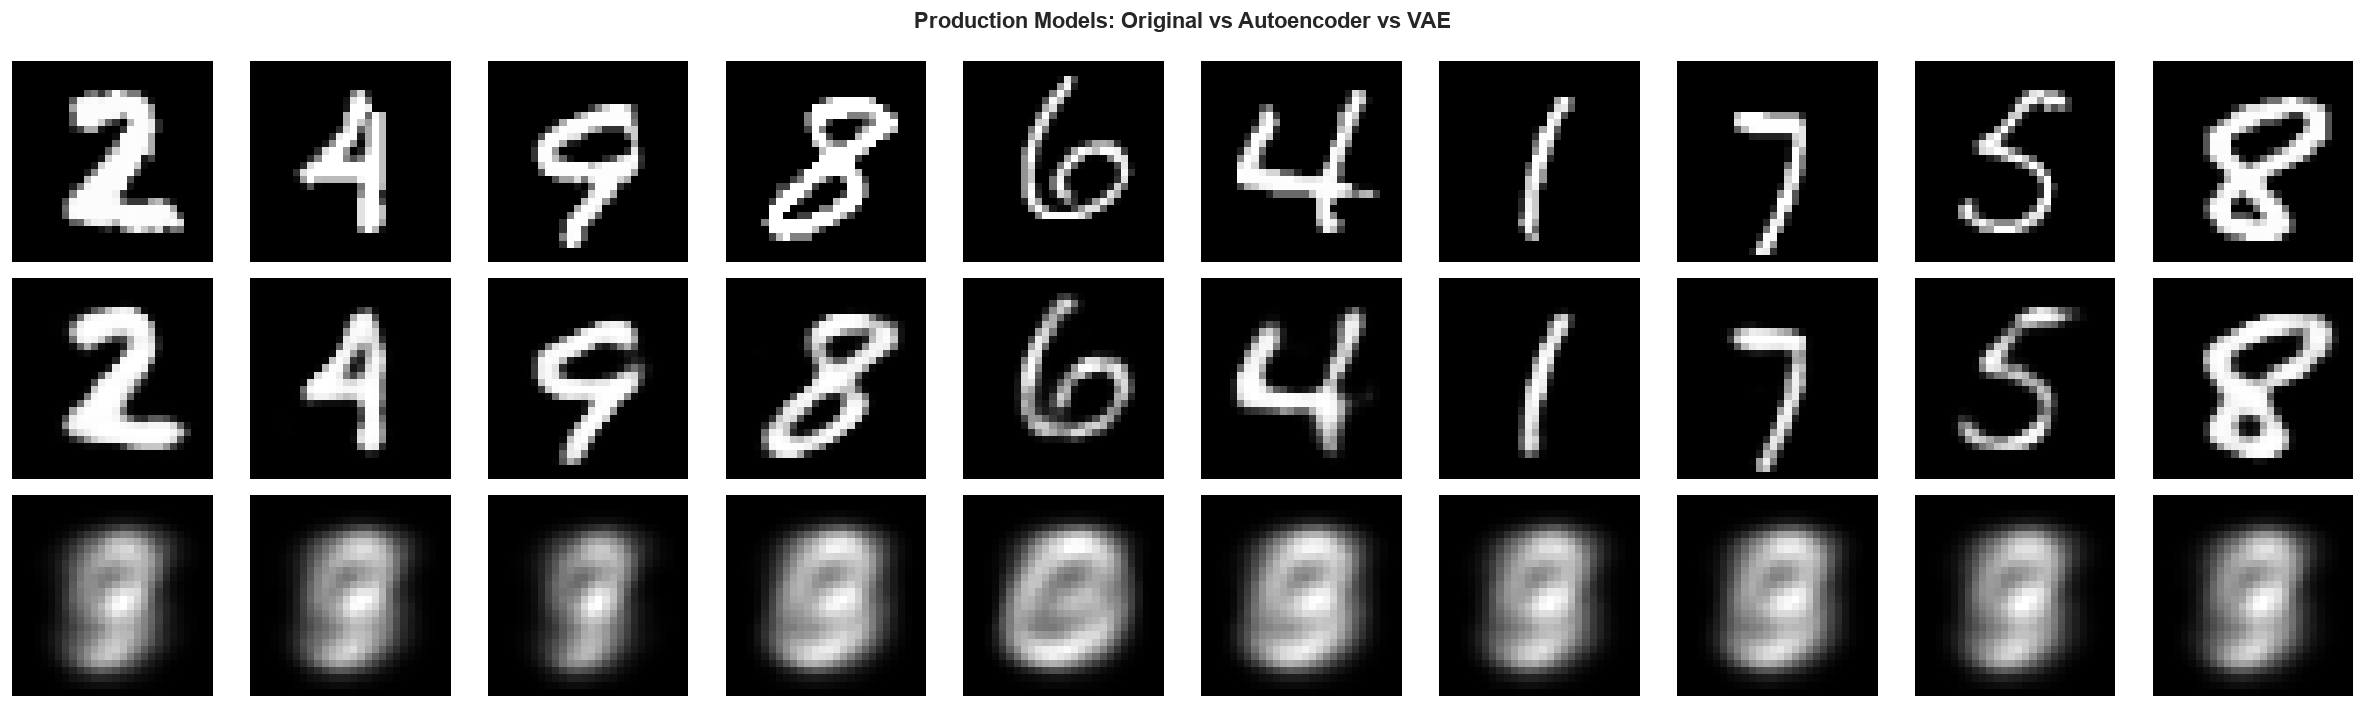

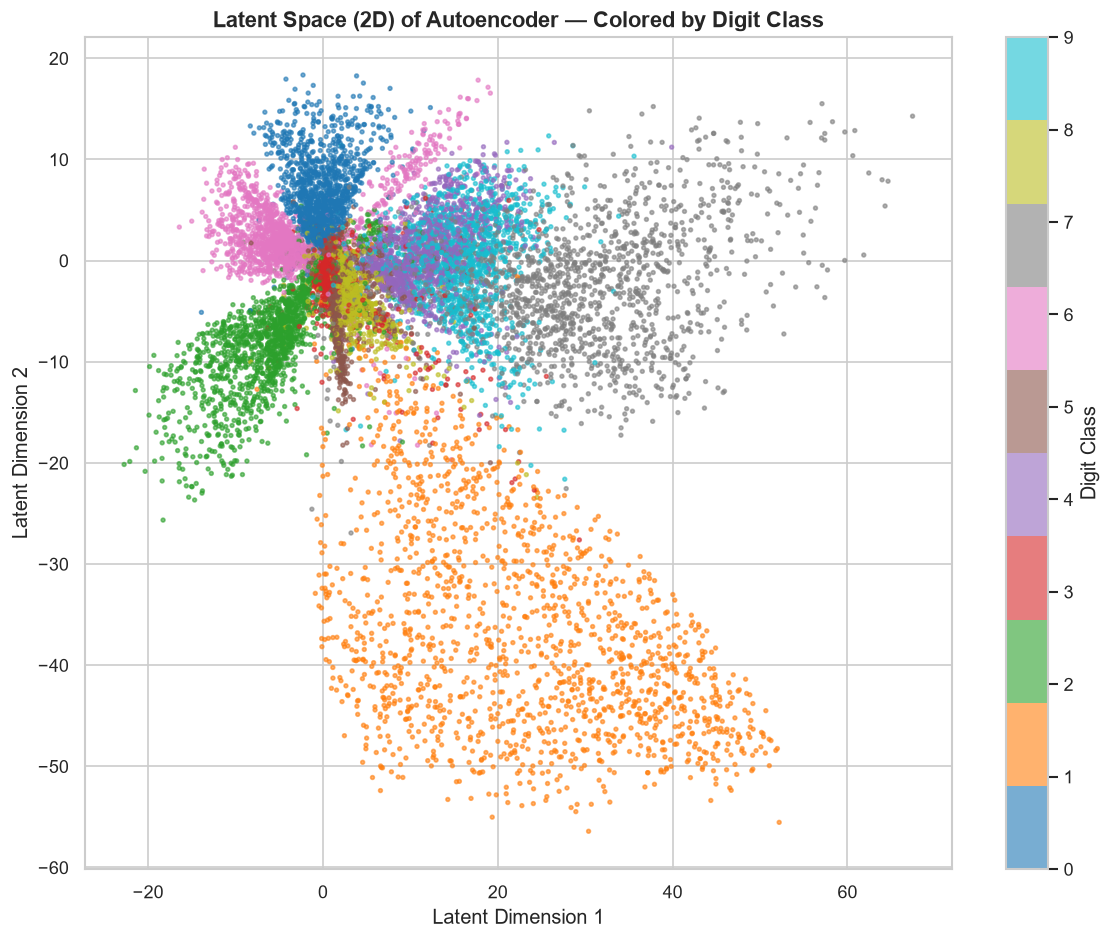

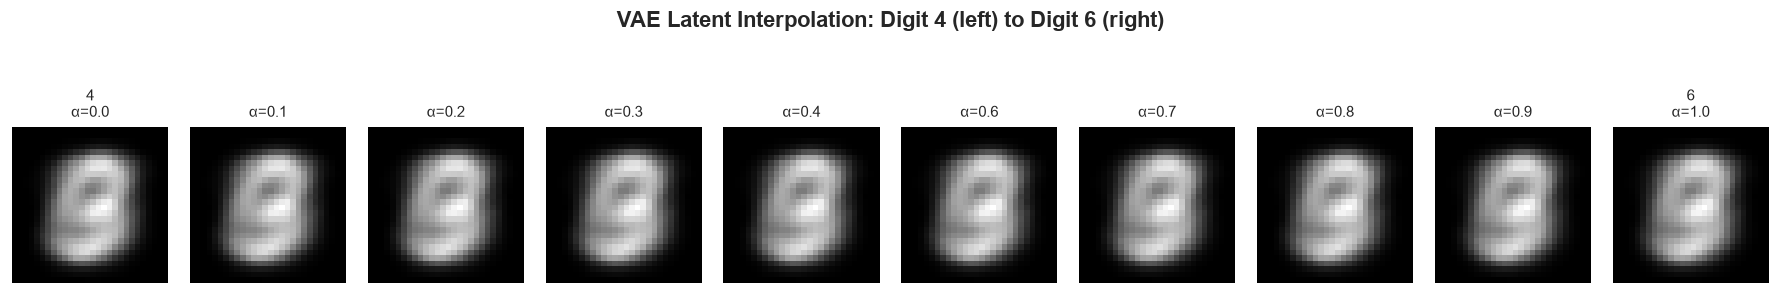

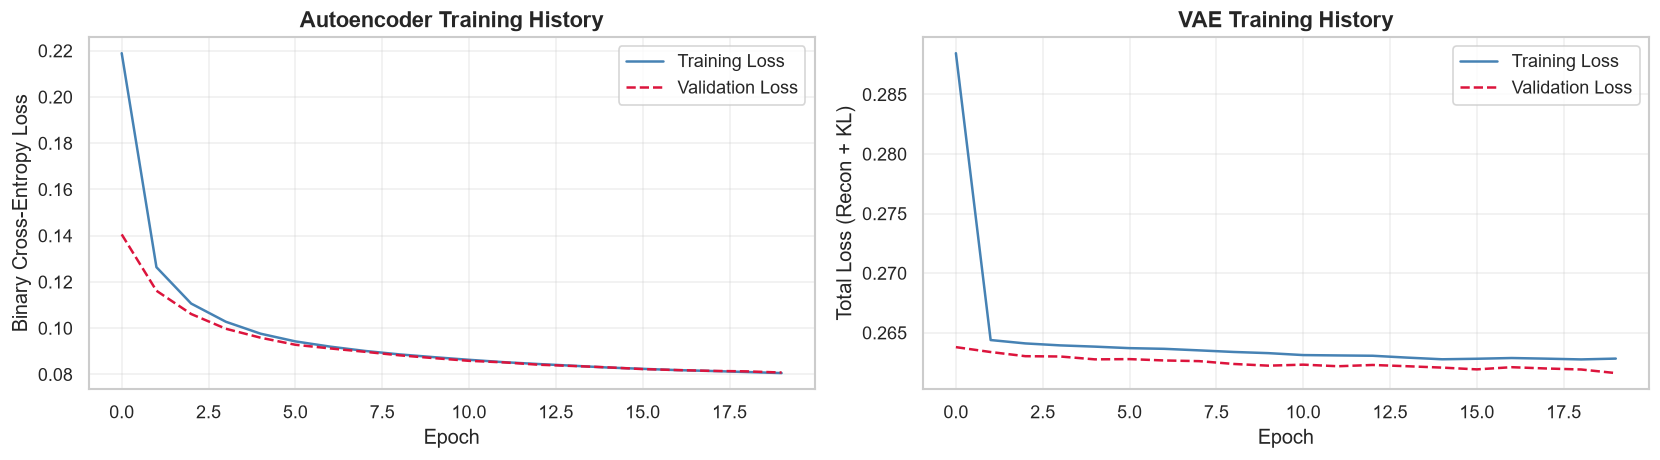


Observations:
- The Autoencoder produces sharper reconstructions but its latent space may have gaps.
- The VAE produces slightly blurrier reconstructions but its latent space is smooth
  and continuous, which enables generating new digits by sampling.
- The 10 digit classes naturally cluster in latent space even without labels.
- VAE interpolation shows smooth transitions between digits, proving a continuous
  latent space.


In [6]:
# =====================================================
# 1. PRODUCTION AUTOENCODER (TensorFlow/Keras)
# =====================================================

latent_dim = 32

# Encoder
encoder_input = keras.Input(shape=(784,))
x = layers.Dense(256, activation='relu')(encoder_input)
x = layers.Dense(128, activation='relu')(x)
z = layers.Dense(latent_dim, name='latent')(x)
encoder = Model(encoder_input, z, name='encoder')

# Decoder
decoder_input = keras.Input(shape=(latent_dim,))
x = layers.Dense(128, activation='relu')(decoder_input)
x = layers.Dense(256, activation='relu')(x)
decoder_output = layers.Dense(784, activation='sigmoid')(x)
decoder = Model(decoder_input, decoder_output, name='decoder')

# Full autoencoder
autoencoder = Model(encoder_input, decoder(encoder(encoder_input)), name='autoencoder')
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

print("Autoencoder Summary:")
autoencoder.summary()

# Train
history_ae = autoencoder.fit(
    X_train, X_train,
    epochs=20,
    batch_size=256,
    validation_data=(X_test, X_test),
    verbose=2,
    shuffle=True
)

# =====================================================
# 2. PRODUCTION VAE (TensorFlow/Keras)
# =====================================================

latent_dim_vae = 32

# Sampling layer (reparameterization trick)
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = keras.ops.shape(z_mean)[0]
        dim = keras.ops.shape(z_mean)[1]
        epsilon = keras.random.normal(shape=(batch, dim))
        return z_mean + keras.ops.exp(0.5 * z_log_var) * epsilon

# Encoder
vae_encoder_input = keras.Input(shape=(784,))
x = layers.Dense(256, activation='relu')(vae_encoder_input)
x = layers.Dense(128, activation='relu')(x)
z_mean = layers.Dense(latent_dim_vae, name='z_mean')(x)
z_log_var = layers.Dense(latent_dim_vae, name='z_log_var')(x)
z = Sampling()([z_mean, z_log_var])
vae_encoder = Model(vae_encoder_input, [z_mean, z_log_var, z], name='vae_encoder')

# Decoder
vae_decoder_input = keras.Input(shape=(latent_dim_vae,))
x = layers.Dense(128, activation='relu')(vae_decoder_input)
x = layers.Dense(256, activation='relu')(x)
vae_decoder_output = layers.Dense(784, activation='sigmoid')(x)
vae_decoder = Model(vae_decoder_input, vae_decoder_output, name='vae_decoder')

# Custom VAE model with custom loss
class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstructed = self.decoder(z)
        kl_loss = -0.5 * keras.ops.mean(
            1 + z_log_var - keras.ops.square(z_mean) - keras.ops.exp(z_log_var)
        )
        self.add_loss(kl_loss)
        return reconstructed
vae = VAE(vae_encoder, vae_decoder)
vae.compile(optimizer='adam', loss='binary_crossentropy')

print("\n\nVAE Summary:")
vae.encoder.summary()
vae.decoder.summary()

# Train
history_vae = vae.fit(
    X_train, X_train,
    epochs=20,
    batch_size=256,
    validation_data=(X_test, X_test),
    verbose=2,
    shuffle=True
)

# =====================================================
# 3. COMPARE RECONSTRUCTIONS
# =====================================================

n_show = 10
indices = np.random.choice(X_test.shape[0], n_show, replace=False)
original_test = X_test[indices]
ae_recon = autoencoder.predict(original_test, verbose=0)
vae_recon = vae.predict(original_test, verbose=0)

fig, axes = plt.subplots(3, n_show, figsize=(2 * n_show, 6))
fig.suptitle("Production Models: Original vs Autoencoder vs VAE",
             fontsize=13, fontweight='bold')
for i in range(n_show):
    axes[0, i].imshow(original_test[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel("Original", fontsize=10)
    axes[1, i].imshow(ae_recon[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel("AE", fontsize=10)
    axes[2, i].imshow(vae_recon[i].reshape(28, 28), cmap='gray')
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_ylabel("VAE", fontsize=10)
plt.tight_layout()
plt.savefig('production_ae_vae_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# =====================================================
# 4. LATENT SPACE VISUALIZATION (2D AE)
# =====================================================

enc_2d_input = keras.Input(shape=(784,))
x = layers.Dense(256, activation='relu')(enc_2d_input)
x = layers.Dense(128, activation='relu')(x)
z_2d = layers.Dense(2, name='latent_2d')(x)
encoder_2d = Model(enc_2d_input, z_2d, name='encoder_2d')

dec_2d_input = keras.Input(shape=(2,))
x = layers.Dense(128, activation='relu')(dec_2d_input)
x = layers.Dense(256, activation='relu')(x)
dec_2d_output = layers.Dense(784, activation='sigmoid')(x)
decoder_2d = Model(dec_2d_input, dec_2d_output, name='decoder_2d')

ae_2d = Model(enc_2d_input, decoder_2d(encoder_2d(enc_2d_input)), name='ae_2d')
ae_2d.compile(optimizer='adam', loss='binary_crossentropy')
ae_2d.fit(X_train, X_train, epochs=15, batch_size=256, verbose=0, shuffle=True)

latent_2d = encoder_2d.predict(X_test, verbose=0)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(latent_2d[:, 0], latent_2d[:, 1], c=y_test,
                     cmap='tab10', alpha=0.6, s=5)
ax.set_title("Latent Space (2D) of Autoencoder — Colored by Digit Class",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Latent Dimension 1")
ax.set_ylabel("Latent Dimension 2")
cbar = plt.colorbar(scatter, ax=ax, ticks=range(10))
cbar.set_label("Digit Class")
plt.tight_layout()
plt.savefig('latent_space_2d_ae.png', dpi=150, bbox_inches='tight')
plt.show()
# =====================================================
# 5. VAE LATENT INTERPOLATION
# =====================================================

idx_1 = np.random.choice(X_test.shape[0])
idx_2 = np.random.choice(X_test.shape[0])
z_mean_1, _, _ = vae.encoder.predict(X_test[idx_1:idx_1+1], verbose=0)
z_mean_2, _, _ = vae.encoder.predict(X_test[idx_2:idx_2+1], verbose=0)
digit_1 = y_test[idx_1]
digit_2 = y_test[idx_2]

alphas = np.linspace(0, 1, 10)
fig, axes = plt.subplots(1, 10, figsize=(15, 3))
fig.suptitle(f"VAE Latent Interpolation: Digit {digit_1} (left) to Digit {digit_2} (right)",
             fontsize=13, fontweight="bold")
for i, alpha in enumerate(alphas):
    z_interp = (1 - alpha) * z_mean_1 + alpha * z_mean_2
    gen_img = vae.decoder.predict(z_interp, verbose=0).reshape(28, 28)
    axes[i].imshow(gen_img, cmap="gray")
    axes[i].axis("off")
    if i == 0:
        axes[i].set_title(f"{digit_1}\n\u03b1=0.0", fontsize=9)
    elif i == len(alphas) - 1:
        axes[i].set_title(f"{digit_2}\n\u03b1=1.0", fontsize=9)
    else:
        axes[i].set_title(f"\u03b1={alpha:.1f}", fontsize=9)
plt.tight_layout()
plt.savefig("vae_interpolation.png", dpi=150, bbox_inches="tight")
plt.show()

# =====================================================
# 6. TRAINING LOSS CURVES
# =====================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_ae.history['loss'], label='Training Loss', color='steelblue')
axes[0].plot(history_ae.history['val_loss'], label='Validation Loss', color='crimson', linestyle='--')
axes[0].set_title("Autoencoder Training History", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_vae.history['loss'], label='Training Loss', color='steelblue')
axes[1].plot(history_vae.history['val_loss'], label='Validation Loss', color='crimson', linestyle='--')
axes[1].set_title("VAE Training History", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Total Loss (Recon + KL)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 60)
print("Observations:")
print("- The Autoencoder produces sharper reconstructions but its latent space may have gaps.")
print("- The VAE produces slightly blurrier reconstructions but its latent space is smooth")
print("  and continuous, which enables generating new digits by sampling.")
print("- The 10 digit classes naturally cluster in latent space even without labels.")
print("- VAE interpolation shows smooth transitions between digits, proving a continuous")
print("  latent space.")
print("=" * 60)

---

# PART 4 — HYPERPARAMETERS + INTERVIEW CORNER

---

## Hyperparameters Explained

### Latent Dimension

**What it is:** The size of the bottleneck layer (e.g., 2, 8, 16, 32). Controls how much information survives compression.

**Effect:**
- **Too small (2-8):** Aggressive compression. Reconstructions are blurry and may confuse digits.
- **Too large (128-784):** Mild compression. The model can cheat by copying near-identity features.
- **Rule of thumb:** Start at 32. Halve it and compare reconstruction quality. Stop when quality drops.

**In our experiments:** 32 gives crisp reconstructions; 2 shows clear clustering in the scatter plot.

### Batch Size

**What it is:** Number of samples processed before each weight update. A batch of 256 means 256 images, averaged errors, then one weight adjustment.

**Effect:**
- **Small (32-64):** Frequent, noisy updates. Can escape poor minima but more iterations per epoch.
- **Large (512-1024):** Smoother gradients, faster per epoch, may converge to sharper minima.
- **Rule of thumb:** 256 balances speed and stability for datasets of 10k-100k samples.

### Epochs

**What it is:** One full pass through every training image.

**Effect:**
- **Too few (1-5):** Underfitting -- model has not learned data patterns.
- **Too many (>100):** Overfitting -- model memorizes noise and specific examples.
- **Rule of thumb:** Train until validation loss stops decreasing for 5-10 consecutive epochs.

**In our experiments:** 20 epochs is sufficient; loss curves flatten well before epoch 20.

### Learning Rate

**What it is:** Step size for gradient descent. Controls how far the optimizer moves per update.

**Effect:**
- **Too high (>0.1):** Optimizer overshoots the minimum. Loss may oscillate or diverge.
- **Too low (<1e-6):** Negligible progress per step. Model may appear stuck.
- **Rule of thumb:** Adam at 1e-3 works across many problems. Reduce to 1e-4 if loss plateaus.

**Note:** Adam adapts the learning rate per parameter, making it much more forgiving than plain SGD.

## Interview Corner

### Q1: What is an Autoencoder?

**Answer:** Think of an autoencoder as a photocopier that learns what matters. You feed it an image, it squeezes it through a narrow passage (bottleneck), and then tries to reconstruct it on the other side. The three components are:

- **Encoder:** Compresses the input into a compact code.
- **Bottleneck (latent space):** The compressed representation — holds only the most essential information.
- **Decoder:** Uncompresses the code back to the original format.

The network is trained end-to-end to minimize the difference between input and reconstruction. Because the bottleneck is narrow, the model cannot simply memorize every pixel; it must discover the underlying structure in the data. This makes autoencoders a form of **unsupervised representation learning**.

**Real-world use:** Anomaly detection in manufacturing — train an autoencoder on images of good products; when a defective product passes through, the reconstruction error spikes.

### Q2: What is a Variational Autoencoder (VAE)?

**Answer:** A VAE is an autoencoder that learns a probability distribution instead of a single point in latent space. The encoder outputs two values: a mean and a variance. The latent vector is then sampled from a Gaussian distribution defined by these parameters.

Two things make a VAE special:

1. **Reparameterization trick:** Sampling is random, which would normally block gradient flow. The trick moves the randomness to an auxiliary noise variable so that backpropagation still works.
2. **KL divergence loss:** This regularizer pulls the learned distributions toward a standard normal (mean=0, variance=1). It prevents the latent space from stretching out and forces different inputs to have overlapping distributions.

The result is a **smooth, continuous latent space** with no gaps. You can interpolate between two points and get realistic outputs at every step — something a standard autoencoder cannot do.

**Real-world use:** Generating new product designs, data augmentation for rare classes, and drug molecule generation.

### Q3: What is Latent Space?

**Answer:** Latent space is the compressed, low-dimensional representation that sits at the bottleneck of an autoencoder. It is "latent" because these dimensions are not explicitly defined by a human — the network discovers them on its own. Each dimension might encode a meaningful visual property (stroke width, slant angle, loop presence), but these features emerge organically from the training data.

Think of it as a map: every input maps to a point on this map, and similar inputs map to nearby points. MNIST digits form 10 clusters on this map even though the autoencoder never saw a single label.

**Key property:** The latent space is the interface between compression and generation. In a VAE, you can pick any point on this map and decode it into a new, never-before-seen image.

### Q4: Why use Autoencoders for Dimensionality Reduction?

**Answer:** Three reasons:

1. **Nonlinearity:** PCA can only find linear combinations of pixels. Autoencoders with activation functions (ReLU, sigmoid) can model curves, loops, and other nonlinear patterns that are essential for representing images.
2. **Data specificity:** Autoencoders learn the optimal compression for a specific dataset. An autoencoder trained on digits learns a different latent space than one trained on fashion items — each is tailored to its domain.
3. **Scalability:** Computing PCA on a 784×784 covariance matrix costs O(n^3). Autoencoders trained with mini-batch gradient descent scale linearly with data size.

**When to choose autoencoders over PCA:** Image data, text embeddings, audio, and any domain where relationships between features are nonlinear.

### Q5: Autoencoder vs PCA?

**Answer:** PCA and autoencoders both do dimensionality reduction, but they differ fundamentally:

| Aspect | PCA | Autoencoder |
|---|---|---|
| **Linearity** | Linear only | Can be nonlinear (with activations) |
| **Solution** | Closed-form (eigenvalue decomposition) | Iterative (gradient descent) |
| **Determinism** | Always gives the same result | Depends on initialization and random seed |
| **Interpretability** | Principal components are explicit axes | Latent dimensions emerge implicitly |
| **Computation** | O(n^3) for covariance matrix | O(epochs x batch_size x parameters) |
| **Expressiveness** | Limited to linear subspaces | Can learn complex manifolds |

**Fun fact:** A linear autoencoder (no hidden layers, no activations, MSE loss) learns exactly the same subspace as PCA. Adding ReLU activations breaks the linearity and opens up richer representations.

**When to use what:** Use PCA for quick, interpretable, linear reduction on tabular data. Use autoencoders for images, sequences, and any data with nonlinear structure.

---

# KEY TAKEAWAYS

1. **Autoencoders learn to compress without ever seeing a label.** The encoder squeezes input into a bottleneck, the decoder reconstructs, and the reconstruction error teaches both parts what matters. No human annotations needed.

2. **VAEs turn latent space into a generative canvas.** By learning distributions (mean + variance) instead of points, VAEs create a smooth space where every nearby point decodes into a realistic image. Standard autoencoders leave gaps; VAEs fill them.

3. **Autoencoders beat PCA when data has nonlinear structure.** PCA finds straight-line patterns. Autoencoders with ReLU activations find curves, loops, edges, and any nonlinear relationship — essential for images, audio, and text.

4. **NumPy is for learning; frameworks are for production.** Manual backpropagation teaches the fundamentals, but TensorFlow/PyTorch are necessary for automatic differentiation, GPU training, and advanced optimizers.

5. **Latent space naturally clusters without supervision.** When projected to 2D, MNIST digits form 10 distinct clusters in an autoencoder's latent space — even though the model was never told what a "4" or a "9" is. The structure is discovered, not taught.